<a href="https://colab.research.google.com/github/blakeaustin21481275/21481275-smart-finance-assistant/blob/main/week8_workshop2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting Stock Data with APIs
**Learn to fetch real stock prices and create simple visualizations**

## What You'll Build
A simple tool that gets stock price data from a free API and creates a basic chart using pandas plotting.

## Setup

In [1]:
# Install what we need
!pip install pandas requests matplotlib

In [2]:
# Import libraries
import pandas as pd
import requests
import matplotlib.pyplot as plt
from datetime import datetime

## Step 1: Ask AI to Help Choose a Stock API

Let's start by asking Colab's AI about free stock APIs. But for this tutorial, we'll simulate the conversation.
```
Ask Colab AI: 'What are some free stock APIs I can use for learning? I want to get basic stock price data.'

AI Response would suggest options like:
- Alpha Vantage (free tier)
- Yahoo Finance (via yfinance)
- IEX Cloud (free tier)
- Finnhub (free tier)
```
For this tutorial, we'll use Alpha Vantage since it's beginner-friendly.

## Step 2: Ask AI to Help Build the API Call

Let's ask AI to help us structure the API request, you might get something like

In [5]:
def get_stock_data(symbol, api_key="RVUYH32O0V4MQ3IT"):
    """
    Get stock data from Alpha Vantage
    Using 'demo' key for testing (limited data)
    """

    base_url = "https://www.alphavantage.co/query"

    # Parameters for the API call
    params = {
        'function': 'TIME_SERIES_DAILY',
        'symbol': symbol,
        'apikey': api_key,
        'outputsize': 'compact'  # Last 100 days
    }

    try:
        response = requests.get(base_url, params=params)
        data = response.json()
        return data
    except Exception as e:
        return {"error": str(e)}

# Test with demo data (IBM stock)
stock_data = get_stock_data("IBM", api_key="RVUYH32O0V4MQ3IT")
print("Got data keys:", list(stock_data.keys()))
print(stock_data.get("Information", "No 'Information' field found."))

Got data keys: ['Meta Data', 'Time Series (Daily)']
No 'Information' field found.


Alpha Vantage keeps that key just for quick tests, and it only gives you a small sample (IBM daily data) or sometimes just the “Information” notice you’re seeing.

What to do

Sign up (free)
Go to https://www.alphavantage.co/support/#api-key
 and enter your email.
They immediately email you a personal API key—no credit card, no waiting.

Use your key in the code
Replace the default "demo" with the key you receive:
```python
stock_data = get_stock_data("IBM", api_key="YOUR_REAL_KEY_HERE")
print(stock_data.keys())
```

or edit the function call everywhere you need it.

Respect their limits
* The free tier allows 5 calls per minute and 500 calls per day.
* If you need more, they have paid plans.

Once you use your own key, the "Information" message will be replaced with real stock data in the usual "Meta Data" and "Time Series (Daily)" fields.

## Step 3: Ask AI to Help Parse the Data

Can you think of a prompt to the AI to help write the function?  The API returns JSON. Let's ask AI how to convert it to a pandas DataFrame:

In [6]:
def parse_stock_data(stock_data, symbol):
    """Convert API response to pandas DataFrame"""

    # Check if we got valid data
    if "Time Series (Daily)" not in stock_data:
        print("Error: No stock data found")
        print("Available keys:", list(stock_data.keys()))
        return None

    # Extract the time series data
    time_series = stock_data["Time Series (Daily)"]

    # Convert to DataFrame
    df = pd.DataFrame.from_dict(time_series, orient='index')

    # Clean up column names
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

    # Convert to numeric
    df = df.astype(float)

    # Convert index to datetime
    df.index = pd.to_datetime(df.index)

    # Sort by date
    df = df.sort_index()

    # Add symbol column
    df['Symbol'] = symbol

    return df

# Parse the stock data
df = parse_stock_data(stock_data, "IBM")

if df is not None:
    print("Stock data sample:")
    print(df.head())
    print(f"\nData shape: {df.shape}")
else:
    print("Could not parse stock data")

Stock data sample:
               Open      High     Low   Close     Volume Symbol
2025-12-12  310.570  311.0500  303.33  309.24  2953374.0    IBM
2025-12-15  308.985  311.3629  306.35  308.66  3566732.0    IBM
2025-12-16  307.315  307.3800  300.42  303.18  3366878.0    IBM
2025-12-17  303.790  306.2500  303.08  303.32  3130954.0    IBM
2025-12-18  303.150  304.4500  295.70  300.45  5411669.0    IBM

Data shape: (100, 6)


## Step 4: Ask AI to Help Create a Simple Chart

Try this prompt (can you make it better?):

```
How do I create a simple line chart of stock prices using pandas?
```

You might get something like.  Now let's visualize the data:

In [16]:
def plot_stock_price(df, symbol):
    if df is None or df.empty:
        print("No data to plot")
        return

    # One-liner chart: pandas handles everything
    df['Close'].plot(title=f"{symbol} Stock Price").figure.show()

    # Basic stats
    print(f"\n{symbol} Stats")
    print("Latest:", df['Close'].iloc[-1])
    print("High:",   df['Close'].max())
    print("Low:",    df['Close'].min())






NameError: name 'symbol' is not defined

/tmp/ipykernel_1502/438527940.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, period="6mo")
[*********************100%***********************]  1 of 1 completed


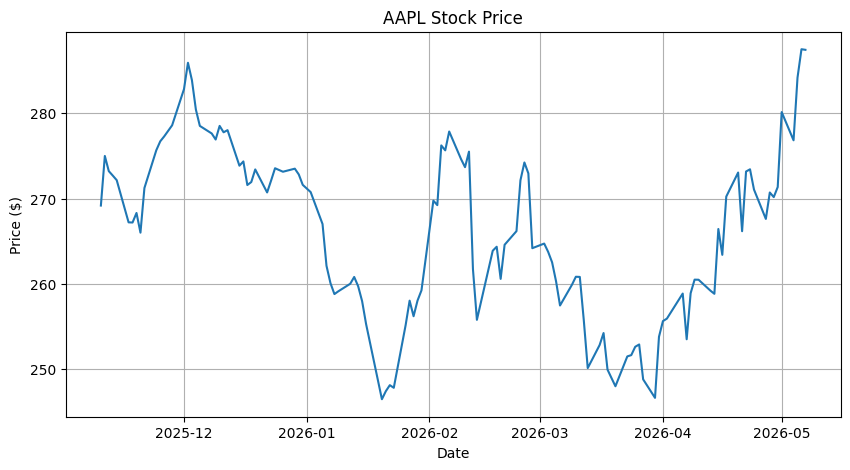


AAPL Stats
Latest: Ticker
AAPL    287.440002
Name: 2026-05-07 00:00:00, dtype: float64
High: Ticker
AAPL    287.51001
dtype: float64
Low: Ticker
AAPL    246.469376
dtype: float64


In [22]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download stock data
symbol = "AAPL"
df = yf.download(symbol, period="6mo")

def plot_stock_price(df, symbol):
    if df is None or df.empty:
        print("No data to plot")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["Close"])
    plt.title(f"{symbol} Stock Price")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.grid(True)
    plt.show()

    print(f"\n{symbol} Stats")
    print("Latest:", df["Close"].iloc[-1])
    print("High:", df["Close"].max())
    print("Low:", df["Close"].min())

plot_stock_price(df, symbol)





## Step 5: Extension Ideas

Let's expand to:
* compare multiple stocks
* build a simple analysis function (see earlier notebook)
* Real-time price updates
* More technical indicators (RSI, MACD)
* Portfolio tracking
* Price alerts
* Integration with a web interface
* Fundamental data (P/E ratios, etc.)
* News sentiment analysis



## Your Turn: Add a Feature

Try adding one feature with AI help:

In [10]:
# Ask AI to help you add a specific feature
# Example: "Help me add a function to calculate the RSI (Relative Strength Index)"

def calculate_rsi(df, window=14):
    """Calculate RSI based on AI suggestions"""

    # This is where you'd implement based on AI help
    print("RSI calculation - ask AI for implementation details")
    return None

# Or ask for help with alerts
def price_alert_system(symbol, target_price, current_price):
    """Simple price alert system"""

    print("Price alert system - ask AI for implementation")
    return None

print("Choose a feature to add and ask Colab AI for help implementing it!")

Choose a feature to add and ask Colab AI for help implementing it!


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

def calculate_rsi(df, period=14):
    """
    Calculate Relative Strength Index (RSI).

    Parameters:
        df (DataFrame): Stock data with a 'Close' column
        period (int): RSI lookback period (default 14)

    Returns:
        DataFrame with RSI column added
    """
    if df is None or df.empty:
        print("No data available")
        return None

    delta = df["Close"].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()

    rs = avg_gain / avg_loss
    df["RSI"] = 100 - (100 / (1 + rs))

    return df

In [12]:
def plot_rsi(df, symbol):
    """
    Plot RSI indicator.
    """
    if df is None or "RSI" not in df.columns:
        print("RSI not calculated")
        return

    plt.figure(figsize=(10, 5))
    plt.plot(df.index, df["RSI"], label="RSI")
    plt.axhline(70, linestyle="--", label="Overbought (70)")
    plt.axhline(30, linestyle="--", label="Oversold (30)")
    plt.title(f"{symbol} RSI Indicator")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

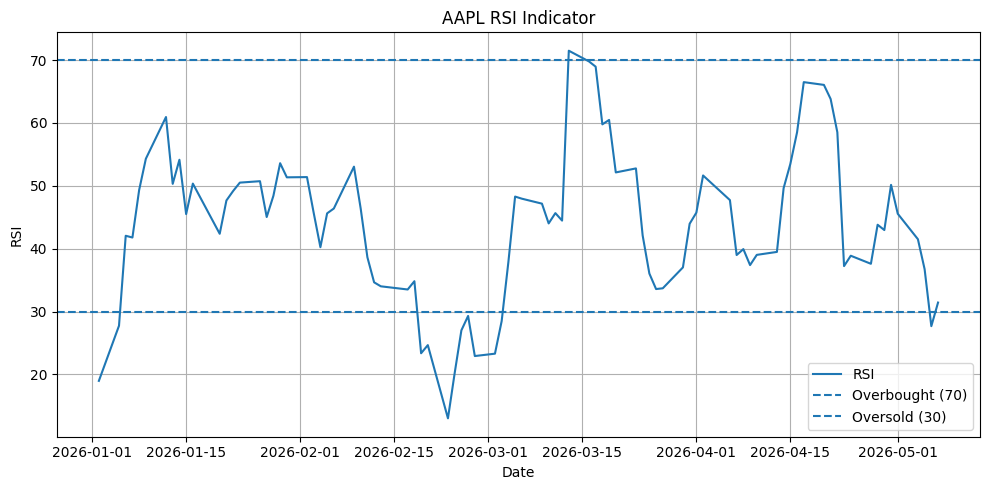

In [13]:
df = calculate_rsi(df)
plot_rsi(df, "AAPL")

## Key Takeaways

You've built a stock analysis tool that:
- Fetches real stock data from an API
- Converts JSON to pandas DataFrames
- Creates visualizations of stock prices
- Calculates basic financial metrics
- Compares multiple stocks

This demonstrates core skills for financial applications:
- API integration
- Data processing with pandas
- Basic financial analysis
- Data visualization

## Next Steps

- Get a real Alpha Vantage API key for more data
- Add more technical indicators
- Combine with the chatbot tutorial
- Build a Gradio interface for user interaction
- Integrate with portfolio tracking

The foundation you've built here can be extended into sophisticated financial analysis tools!